In [18]:
import pandas as pd
import h3
import matplotlib.pyplot as plt

# Load the trip data.
df = pd.read_csv("../assets/Taxi_Trips_sample.parquet")

In [19]:
df

,trip_id_int,taxi_id_int,trip_start,trip_end,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,has_electronic_fee
0,1,1.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1269,13.04,56.0,39.0,33.00,7.70,0.0,5.0,46.20,credit card,taxicab insurance agency llc,41.792592,-87.769615,41.808916,-87.596183,True
1,2,2.0,2026-05-01 00:00:00,2026-05-01 00:00:00,422,1.57,32.0,28.0,7.36,0.00,0.0,0.0,7.86,mobile,flash cab,41.878866,-87.625192,41.874005,-87.663518,True
2,3,3.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1083,9.93,76.0,NaN,26.25,0.00,0.0,5.0,31.25,cash,5 star taxi,41.980264,-87.913625,NaN,NaN,False
3,4,4.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1980,13.90,56.0,8.0,37.50,0.00,0.0,4.0,41.50,cash,transit administrative center inc,41.792592,-87.769615,41.899602,-87.633308,False
4,5,5.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1967,16.39,7.0,71.0,42.75,8.65,0.0,0.0,51.40,prcard,city service,41.922686,-87.649489,41.744205,-87.656306,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1023.0,2026-04-25 13:45:00,2026-04-25 14:00:00,1050,2.58,8.0,24.0,12.04,0.00,0.0,0.0,12.54,mobile,taxicab insurance agency llc,41.899602,-87.633308,41.901207,-87.676356,True
99996,99997,1038.0,2026-04-25 13:45:00,2026-04-25 14:15:00,1347,4.52,8.0,7.0,18.00,3.70,0.0,0.0,22.20,credit card,blue ribbon taxi association,41.891972,-87.612945,41.921877,-87.664078,True
99997,99998,1314.0,2026-04-25 13:45:00,2026-04-25 14:00:00,1039,7.90,8.0,41.0,22.50,0.00,0.0,2.0,24.50,cash,sun taxi,41.899602,-87.633308,41.794090,-87.592311,False
99998,99999,391.0,2026-04-25 13:45:00,2026-04-25 14:00:00,712,1.11,8.0,8.0,8.00,0.00,0.0,0.0,8.00,cash,chicago independents,41.899156,-87.626211,41.891972,-87.612945,False


In [20]:
import folium
import branca.colormap as cm
from IPython.display import display
import geopandas
from shapely.geometry import shape

H3_HEXAGON_RESOLUTION = 8


def to_h3_cell(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return None
    return h3.latlng_to_cell(float(lat), float(lon), H3_HEXAGON_RESOLUTION)


# Assign each trip start and end to an H3 hexagon.

df["start_h3"] = df.apply(lambda row: h3.latlng_to_cell(row["pickup_lat"], row["pickup_lon"], H3_HEXAGON_RESOLUTION) if (row['pickup_lat'] and row['pickup_lon']) else 0, axis=1)
df["end_h3"] = df.apply(lambda row: h3.latlng_to_cell(row["dropoff_lat"], row["dropoff_lon"], H3_HEXAGON_RESOLUTION) if (row['dropoff_lat'] and row['dropoff_lon']) else 0, axis=1)

trips_starts = df.groupby('start_h3').count()['id'].reset_index().rename(columns={'id': 'count'})
trips_starts['geometry'] = trips_starts.apply(lambda x: shape(h3.cells_to_geo([x["start_h3"]])), axis=1)

trips_ends = df.groupby('h3_hexend_h3_id_end').count()['id'].reset_index().rename(columns={'id': 'count'})
trips_ends['geometry'] = trips_starts.apply(lambda x: shape(h3.cells_to_geo([x["end_h3"]])), axis=1)

trips_starts_geo = geopandas.GeoDataFrame(trips_starts, geometry=trips_starts['geometry'], crs='EPSG:4326')
trips_ends_geo = geopandas.GeoDataFrame(trips_ends, geometry=trips_ends['geometry'], crs='EPSG:4326')


if trips_starts.empty and trips_ends.empty:
    raise ValueError("No valid pickup or dropoff coordinates were found for H3 mapping.")

all_latitudes = pd.concat([df["pickup_lat"], df["dropoff_lat"]], ignore_index=True).dropna()
all_longitudes = pd.concat([df["pickup_lon"], df["dropoff_lon"]], ignore_index=True).dropna()
map_center = [all_latitudes.mean(), all_longitudes.mean()]
max_count = int(max(trips_starts.max() if not trips_starts.empty else 0, trips_ends.max() if not trips_ends.empty else 0))
colormap = cm.linear.YlOrRd_09.scale(0, max_count)
colormap.caption = "Trips per H3 hexagon"

m = folium.Map(location=map_center, zoom_start=11, tiles="CartoDB positron")


def add_hex_layer(map_object, counts, layer_name, show_layer):
    layer = folium.FeatureGroup(name=layer_name, show=show_layer)
    for h3_cell, count in counts.items():
        boundary = h3.cell_to_boundary(h3_cell)
        folium.Polygon(
            locations=[[lat, lon] for lat, lon in boundary],
            color=colormap(count),
            weight=1,
            fill=True,
            fill_color=colormap(count),
            fill_opacity=0.65,
            tooltip=folium.Tooltip(f"{layer_name}: {count:,} trips"),
        ).add_to(layer)
    layer.add_to(map_object)


add_hex_layer(m, trips_starts, "Start trip hexagons", True)
add_hex_layer(m, trips_ends, "End trip hexagons", False)
colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

display(m)

H3LatLngDomainError: 

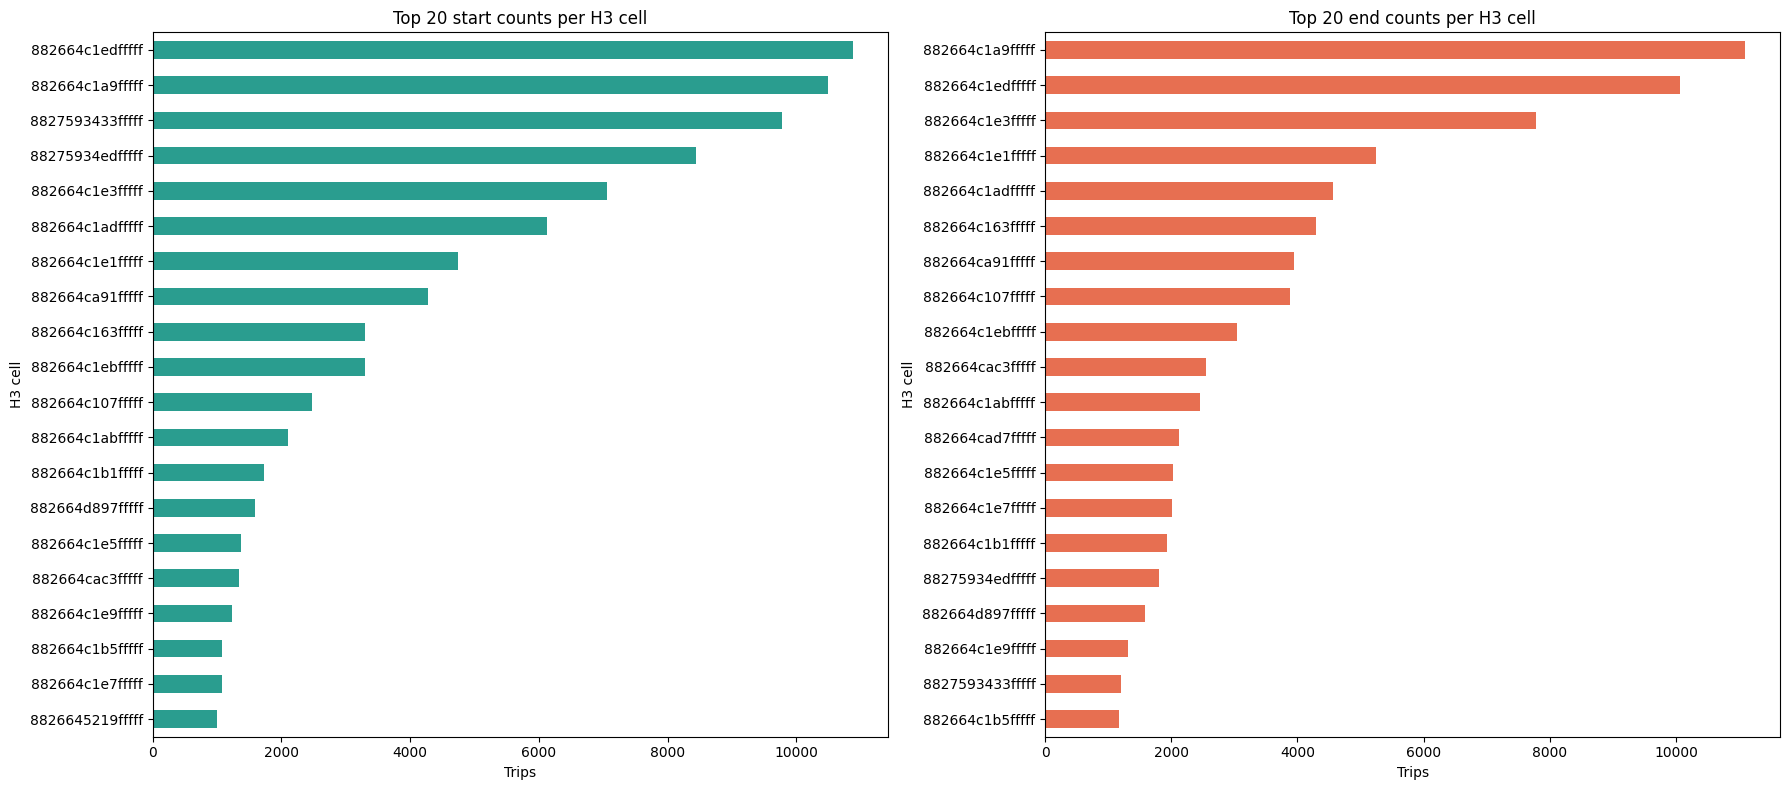

In [15]:
top_n = 20
start_counts_top = start_counts.sort_values(ascending=False).head(top_n).sort_values(ascending=True)
end_counts_top = end_counts.sort_values(ascending=False).head(top_n).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

start_counts_top.plot(kind="barh", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 20 start counts per H3 cell")
axes[0].set_xlabel("Trips")
axes[0].set_ylabel("H3 cell")

end_counts_top.plot(kind="barh", ax=axes[1], color="#e76f51")
axes[1].set_title("Top 20 end counts per H3 cell")
axes[1].set_xlabel("Trips")
axes[1].set_ylabel("H3 cell")

plt.tight_layout()

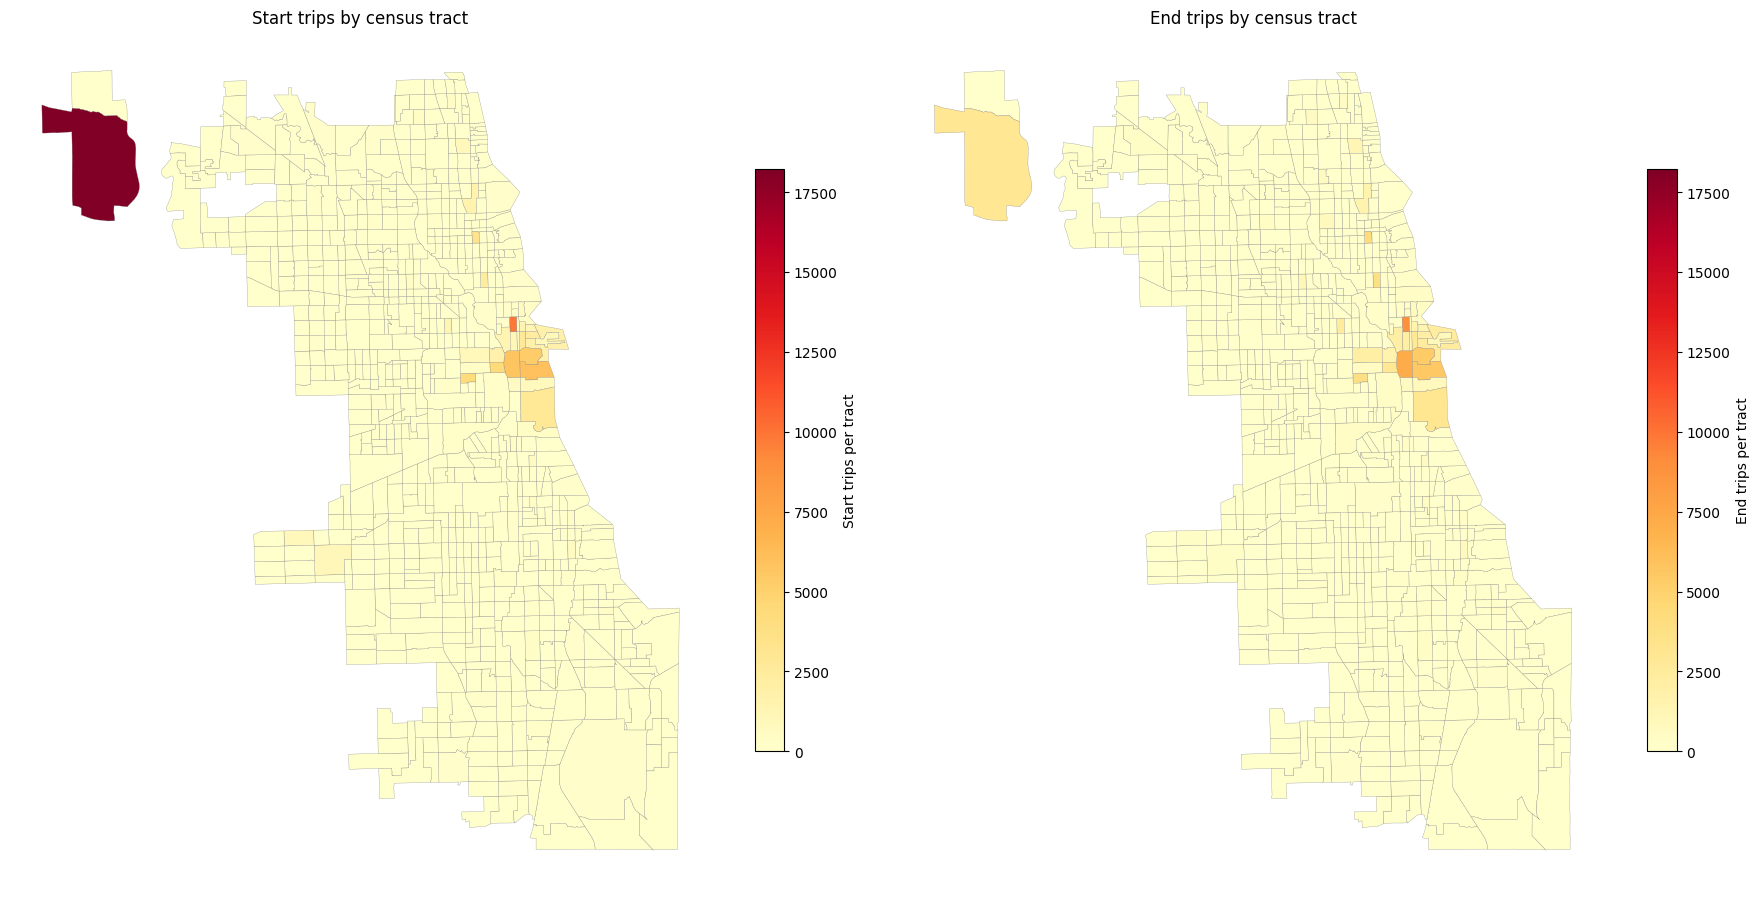

In [ ]:
import geopandas as gpd

# Aggregate trips by census tract and plot separate tract-level heatmaps for starts and ends
tracts = gpd.read_file("../assets/Boundaries - Census Tracts - 2010.geojson").to_crs("EPSG:4326")

# Create point GeoDataFrames for starts and ends
starts = gpd.GeoDataFrame(df[["pickup_lon", "pickup_lat"]].copy(),
                          geometry=gpd.points_from_xy(df["pickup_lon"], df["pickup_lat"]),
                          crs="EPSG:4326")
ends = gpd.GeoDataFrame(df[["dropoff_lon", "dropoff_lat"]].copy(),
                        geometry=gpd.points_from_xy(df["dropoff_lon"], df["dropoff_lat"]),
                        crs="EPSG:4326")

# Spatial join points -> tracts
starts_join = gpd.sjoin(starts, tracts[["geoid10", "geometry"]], how="left", predicate="within")
ends_join = gpd.sjoin(ends, tracts[["geoid10", "geometry"]], how="left", predicate="within")

# Count per tract
starts_counts = starts_join.groupby("geoid10").size().rename("start_count")
ends_counts = ends_join.groupby("geoid10").size().rename("end_count")

# Merge counts into tracts GeoDataFrame
tracts_counts = tracts.set_index("geoid10").join(starts_counts).join(ends_counts)
tracts_counts["start_count"] = tracts_counts["start_count"].fillna(0).astype(int)
tracts_counts["end_count"] = tracts_counts["end_count"].fillna(0).astype(int)
tracts_counts["total_trips"] = tracts_counts["start_count"] + tracts_counts["end_count"]

# Determine common color scale
vmax = max(tracts_counts["start_count"].max(), tracts_counts["end_count"].max())

# Plot start and end tract heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True, sharey=True)

tracts_counts.plot(column="start_count",
                   ax=axes[0],
                   cmap="YlOrRd",
                   linewidth=0.2,
                   edgecolor="grey",
                   vmin=0,
                   vmax=vmax,
                   legend=True,
                   legend_kwds={"label": "Start trips per tract", "shrink": 0.6})
axes[0].set_title("Start trips by census tract")
axes[0].set_axis_off()

tracts_counts.plot(column="end_count",
                   ax=axes[1],
                   cmap="YlOrRd",
                   linewidth=0.2,
                   edgecolor="grey",
                   vmin=0,
                   vmax=vmax,
                   legend=True,
                   legend_kwds={"label": "End trips per tract", "shrink": 0.6})
axes[1].set_title("End trips by census tract")
axes[1].set_axis_off()

plt.tight_layout()

In [ ]:
df.head()

---

# Using Full Dataset

In [22]:
df = pd.read_parquet('../assets/Taxi_Trips_compact.parquet')

In [24]:
df.head()

,trip_id_int,taxi_id_int,trip_start,trip_end,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,has_electronic_fee
0,1,1.0,2026-05-01,2026-05-01 00:15:00,1269,13.04,56.0,39.0,33.00,7.70,0.0,5.0,46.20,credit card,taxicab insurance agency llc,41.792592,-87.769615,41.808916,-87.596183,True
1,2,2.0,2026-05-01,2026-05-01 00:00:00,422,1.57,32.0,28.0,7.36,0.00,0.0,0.0,7.86,mobile,flash cab,41.878866,-87.625192,41.874005,-87.663518,True
2,3,3.0,2026-05-01,2026-05-01 00:15:00,1083,9.93,76.0,NaN,26.25,0.00,0.0,5.0,31.25,cash,5 star taxi,41.980264,-87.913625,NaN,NaN,False
3,4,4.0,2026-05-01,2026-05-01 00:30:00,1980,13.90,56.0,8.0,37.50,0.00,0.0,4.0,41.50,cash,transit administrative center inc,41.792592,-87.769615,41.899602,-87.633308,False
4,5,5.0,2026-05-01,2026-05-01 00:30:00,1967,16.39,7.0,71.0,42.75,8.65,0.0,0.0,51.40,prcard,city service,41.922686,-87.649489,41.744205,-87.656306,False


In [14]:
import folium
import branca.colormap as cm
from IPython.display import display

H3_HEXAGON_RESOLUTION = 8


def to_h3_cell(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return None
    return h3.latlng_to_cell(float(lat), float(lon), H3_HEXAGON_RESOLUTION)


# Assign each trip start and end to an H3 hexagon.
df["start_h3"] = [to_h3_cell(lat, lon) for lat, lon in zip(df["pickup_lat"], df["pickup_lon"])]
df["end_h3"] = [to_h3_cell(lat, lon) for lat, lon in zip(df["dropoff_lat"], df["dropoff_lon"])]

start_counts = df["start_h3"].dropna().value_counts()
end_counts = df["end_h3"].dropna().value_counts()

if start_counts.empty and end_counts.empty:
    raise ValueError("No valid pickup or dropoff coordinates were found for H3 mapping.")

all_latitudes = pd.concat([df["pickup_lat"], df["dropoff_lat"]], ignore_index=True).dropna()
all_longitudes = pd.concat([df["pickup_lon"], df["dropoff_lon"]], ignore_index=True).dropna()
map_center = [all_latitudes.mean(), all_longitudes.mean()]
max_count = int(max(start_counts.max() if not start_counts.empty else 0, end_counts.max() if not end_counts.empty else 0))
colormap = cm.linear.YlOrRd_09.scale(0, max_count)
colormap.caption = "Trips per H3 hexagon"

m = folium.Map(location=map_center, zoom_start=11, tiles="CartoDB positron")


def add_hex_layer(map_object, counts, layer_name, show_layer):
    layer = folium.FeatureGroup(name=layer_name, show=show_layer)
    for h3_cell, count in counts.items():
        boundary = h3.cell_to_boundary(h3_cell)
        folium.Polygon(
            locations=[[lat, lon] for lat, lon in boundary],
            color=colormap(count),
            weight=1,
            fill=True,
            fill_color=colormap(count),
            fill_opacity=0.65,
            tooltip=folium.Tooltip(f"{layer_name}: {count:,} trips"),
        ).add_to(layer)
    layer.add_to(map_object)


add_hex_layer(m, start_counts, "Start trip hexagons", True)
add_hex_layer(m, end_counts, "End trip hexagons", False)
colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

display(m)